#  Practical 10: Image Captioning with Attention Mechanism
## Deep Learning Lab | BTech Semester 4
## KARTIK KUMAR NDU202400012
---

### 🎯 Objective
Implement an **Encoder-Decoder model with Attention** that bridges Computer Vision and NLP — generating textual descriptions from images.

### 📌 What You Will Learn
- Encoder-Decoder architecture for sequence generation
- Bahdanau Attention Mechanism — dynamically weighting image regions
- Using pre-trained CNNs (InceptionV3) as image feature extractors
- Greedy decoding and caption generation
- Visualizing attention maps — what the model "looks at" for each word

### 📚 References
- Vinyals et al. (2015) — *Show and Tell: A Neural Image Caption Generator*
  https://arxiv.org/abs/1411.4555
- Xu et al. (2015) — *Show, Attend and Tell: Neural Image Caption Generation with Visual Attention*
  https://arxiv.org/abs/1502.03044
- Bahdanau et al. (2014) — *Neural Machine Translation by Jointly Learning to Align and Translate*
  https://arxiv.org/abs/1409.0473
- Flickr8k Dataset: https://www.kaggle.com/datasets/adityajn105/flickr8k

---

## 📦 Step 1: Install & Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os, re, json, pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print('Libraries ready!')

TensorFlow: 2.20.0
Libraries ready!


## 🧠 Step 2: Architecture Overview

The Image Captioning system with Attention consists of three major parts:

```
┌────────────────────────────────────────────────────────────────────┐
│                    IMAGE CAPTIONING PIPELINE                       │
├──────────────┬──────────────────────────┬──────────────────────────┤
│   ENCODER    │       ATTENTION          │       DECODER            │
│              │                          │                          │
│ InceptionV3  │  Score each spatial      │  GRU / LSTM              │
│ (Pre-trained)│  feature vs. hidden      │  generates words         │
│              │  state → weights         │  one at a time           │
│ Image (224²) │                          │                          │
│  → Features  │  Context = Σ(αᵢ * fᵢ)   │  ht = GRU(xt, ht-1,     │
│  (8×8×2048)  │  (weighted sum of        │        context)          │
│              │  spatial regions)        │                          │
└──────────────┴──────────────────────────┴──────────────────────────┘
```

**Attention Formula (Bahdanau):**
$$e_{ti} = v^T \tanh(W_1 h_{t-1} + W_2 f_i)$$
$$\alpha_{ti} = \text{softmax}(e_{ti})$$
$$\text{context}_t = \sum_i \alpha_{ti} f_i$$

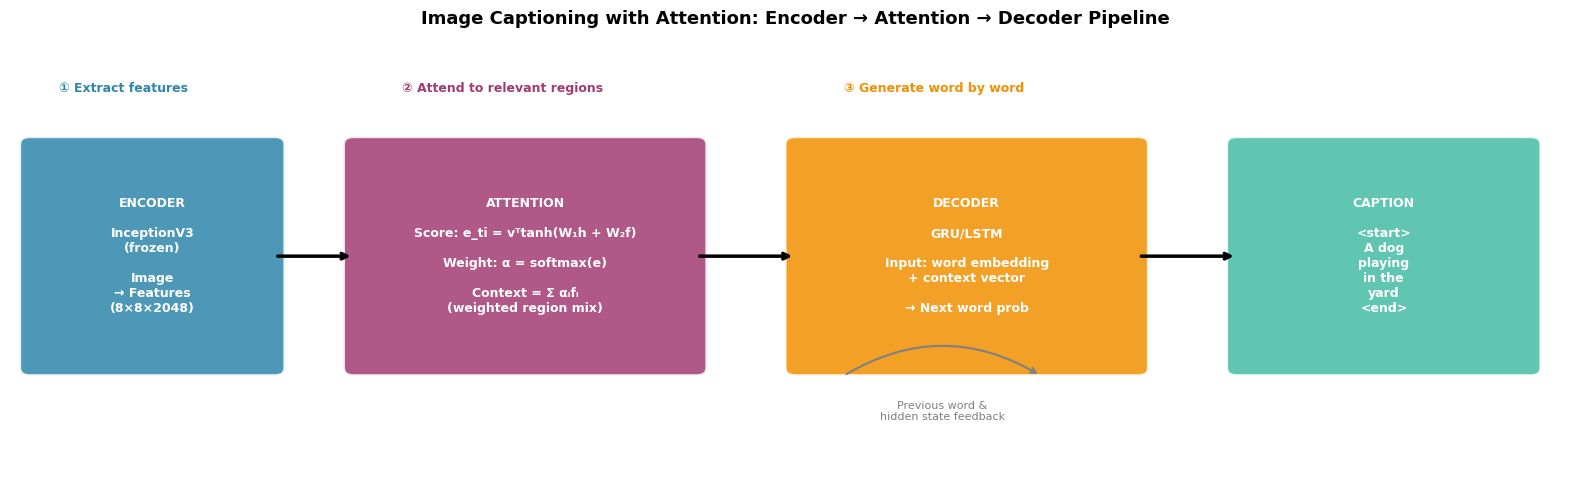

In [2]:
# Visualize the Encoder-Decoder-Attention architecture
fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(0, 16); ax.set_ylim(0, 6); ax.axis('off')

def draw_block(ax, x, y, w, h, text, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', wrap=True)

# Encoder
draw_block(ax, 0.2, 1.5, 2.5, 3, 'ENCODER\n\nInceptionV3\n(frozen)\n\nImage\n→ Features\n(8×8×2048)', '#2E86AB')

# Attention
draw_block(ax, 3.5, 1.5, 3.5, 3, 'ATTENTION\n\nScore: e_ti = vᵀtanh(W₁h + W₂f)\n\nWeight: α = softmax(e)\n\nContext = Σ αᵢfᵢ\n(weighted region mix)', '#A23B72')

# Decoder
draw_block(ax, 8, 1.5, 3.5, 3, 'DECODER\n\nGRU/LSTM\n\nInput: word embedding\n+ context vector\n\n→ Next word prob', '#F18F01')

# Output
draw_block(ax, 12.5, 1.5, 3, 3, 'CAPTION\n\n<start>\nA dog\nplaying\nin the\nyard\n<end>', '#44BBA4')

# Arrows
for x1, x2 in [(2.7, 3.5), (7.0, 8.0), (11.5, 12.5)]:
    ax.annotate('', xy=(x2, 3.0), xytext=(x1, 3.0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

# Feedback loop
ax.annotate('', xy=(8.5, 1.4), xytext=(10.5, 1.4),
            arrowprops=dict(arrowstyle='<-', lw=1.5, color='gray',
                           connectionstyle='arc3,rad=0.3'))
ax.text(9.5, 0.8, 'Previous word &\nhidden state feedback', ha='center', fontsize=8, color='gray')

ax.text(0.5, 5.2, '① Extract features', fontsize=9, color='#2E86AB', fontweight='bold')
ax.text(4.0, 5.2, '② Attend to relevant regions', fontsize=9, color='#A23B72', fontweight='bold')
ax.text(8.5, 5.2, '③ Generate word by word', fontsize=9, color='#F18F01', fontweight='bold')

plt.title('Image Captioning with Attention: Encoder → Attention → Decoder Pipeline',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📂 Step 3: Dataset Setup

**Option A:** Use the Flickr8k dataset from Kaggle (recommended)

**Option B:** Use a small synthetic dataset built-in here (runs without downloads)

In [3]:
# =====================================================================
# OPTION A: real Flickr8k dataset from Kaggle (recommended for proper results)
# =====================================================================
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d adityajn105/flickr8k
# !unzip flickr8k.zip -d flickr8k
# IMAGE_DIR = 'flickr8k/Images'
# CAPTIONS_FILE = 'flickr8k/captions.txt'
# USE_FLICKR = True

# =====================================================================
# OPTION B: generating a small fake dataset so we can run everything without downloading anything
# =====================================================================
USE_FLICKR = False

# creating 50 synthetic image-caption pairs using pre-written caption templates
np.random.seed(42)

# Define vocabulary themes and templates
caption_templates = [
    'a dog is playing in the park',
    'a cat sitting on a wooden chair',
    'two children running on the beach',
    'a red car parked on the street',
    'a man riding a bicycle on the road',
    'a woman holding a yellow umbrella',
    'a group of people standing near a building',
    'a bird flying over the blue water',
    'a young boy kicking a football',
    'an old man reading a newspaper',
    'two dogs running on a green field',
    'a white cat sleeping on a sofa',
    'children playing near a red building',
    'a blue bicycle parked near the road',
    'a man walking with a large dog',
]

# assigning 3 different captions to each image (like how Flickr8k has 5 per image)
N_IMAGES = 50
captions_data = {}
for img_id in range(N_IMAGES):
    selected = np.random.choice(caption_templates, size=3, replace=False)
    captions_data[f'image_{img_id:04d}'] = list(selected)

# creating fake 'images' as random colored arrays — in reality you'd load actual photos here
synthetic_images = {}
for img_id in range(N_IMAGES):
    img = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
    synthetic_images[f'image_{img_id:04d}'] = img

print(f'Synthetic dataset created: {N_IMAGES} images, 3 captions each')
print(f'Sample image IDs: {list(captions_data.keys())[:5]}')
print(f'Sample captions for image_0000:')
for c in captions_data['image_0000']:
    print(f'  → "{c}"')

Synthetic dataset created: 50 images, 3 captions each
Sample image IDs: ['image_0000', 'image_0001', 'image_0002', 'image_0003', 'image_0004']
Sample captions for image_0000:
  → "an old man reading a newspaper"
  → "a white cat sleeping on a sofa"
  → "a dog is playing in the park"


## 📝 Step 4: Text Preprocessing — Build Vocabulary

In [4]:
# collecting every caption from all images into one flat list
all_captions = []
for captions in captions_data.values():
    all_captions.extend(captions)

# cleaning each caption: making it lowercase, removing punctuation, and wrapping with start/end tokens
def clean_caption(caption):
    caption = caption.lower().strip()  # lowercase and remove leading/trailing spaces
    caption = re.sub(r'[^a-zA-Z\s]', '', caption)  # removing anything that's not a letter or space
    return '<start> ' + caption + ' <end>'  # wrapping with special tokens the decoder will use to know where to start and stop

cleaned_captions = [clean_caption(c) for c in all_captions]

# counting how many times each word appears across all captions
word_counts = Counter()
for caption in cleaned_captions:
    word_counts.update(caption.split())

# only keeping words that appear at least twice — rare words get replaced with <unk>
MIN_FREQ = 2
vocab = ['<pad>', '<unk>'] + [w for w, c in word_counts.items() if c >= MIN_FREQ]

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx['<pad>']
START_IDX  = word2idx['<start>']
END_IDX    = word2idx['<end>']

print(f'Total captions: {len(cleaned_captions)}')
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Most common words: {word_counts.most_common(10)}')

# converting each caption from words to a list of integer IDs
def tokenize(caption, word2idx, max_len=20):
    """Convert caption string to sequence of token IDs."""
    tokens = [word2idx.get(w, word2idx['<unk>']) for w in caption.split()]
    return tokens

# Build tokenized sequences
tokenized = [tokenize(c, word2idx) for c in cleaned_captions]

# padding all sequences to the same length so we can batch them
MAX_LEN = max(len(t) for t in tokenized)
padded = pad_sequences(tokenized, maxlen=MAX_LEN, padding='post',
                        truncating='post', value=PAD_IDX)
print(f'Max caption length: {MAX_LEN}')
print(f'Padded captions shape: {padded.shape}')

Total captions: 150
Vocabulary size: 60
Most common words: [('a', 212), ('<start>', 150), ('<end>', 150), ('on', 64), ('the', 60), ('near', 37), ('man', 28), ('cat', 27), ('bicycle', 27), ('road', 27)]
Max caption length: 10
Padded captions shape: (150, 10)


## 🖼️ Step 5: Image Feature Extraction with InceptionV3

InceptionV3 is pre-trained on ImageNet. We extract its spatial feature maps (before the final pooling layer) — these give us a grid of features representing different image regions.

In [5]:
# Build InceptionV3 feature extractor
# We take the output of the last conv layer (before global pooling)
# This gives spatial features: (8, 8, 2048) for a 299x299 input

def build_inception_extractor():
    """InceptionV3 as a spatial feature extractor.

    include_top=False: remove classification head
    pooling=None: keep spatial dimensions (8×8 grid of features)
    Each of the 8×8=64 positions represents a spatial region of the image.
    Each position has 2048 features describing that region.
    """
    base = InceptionV3(weights='imagenet', include_top=False,
                        input_shape=(299, 299, 3))
    base.trainable = False  # locking all weights — we only want to use it as a feature extractor, not fine-tune it
    model = keras.Model(inputs=base.input,
                         outputs=base.output,  # (batch, 8, 8, 2048)
                         name='InceptionV3_Extractor')
    return model


print('Building InceptionV3 feature extractor...')
inception = build_inception_extractor()
print(f'InceptionV3 output shape: {inception.output.shape}')
print('Each image → 8×8=64 spatial regions, each with 2048 features')

# extracting features for every image upfront and storing them
# in a real project you'd save these to disk so you don't recompute every epoch
def preprocess_for_inception(img, size=299):
    """Resize and normalize image for InceptionV3."""
    img_resized = tf.image.resize(img.astype('float32'), [size, size])
    img_norm = keras.applications.inception_v3.preprocess_input(img_resized)
    return img_norm

print('\nPre-extracting image features...')
image_features = {}
img_ids = list(synthetic_images.keys())

# Process in batches
BATCH_SIZE = 10
for i in range(0, len(img_ids), BATCH_SIZE):
    batch_ids = img_ids[i:i+BATCH_SIZE]
    batch_imgs = np.array([preprocess_for_inception(synthetic_images[k]) for k in batch_ids])
    features = inception.predict(batch_imgs, verbose=0)
    # flattening the 8x8 grid into 64 positions — each position is one spatial region
    features_flat = features.reshape(len(batch_ids), -1, features.shape[-1])
    for j, img_id in enumerate(batch_ids):
        image_features[img_id] = features_flat[j]

print(f'Features extracted for {len(image_features)} images')
print(f'Feature shape per image: {image_features["image_0000"].shape}  (64 regions × 2048 features)')

Building InceptionV3 feature extractor...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
InceptionV3 output shape: (None, 8, 8, 2048)
Each image → 8×8=64 spatial regions, each with 2048 features

Pre-extracting image features...
Features extracted for 50 images
Feature shape per image: (64, 2048)  (64 regions × 2048 features)


## 🏗️ Step 6: Build the Attention Mechanism

In [6]:
class BahdanauAttention(layers.Layer):
    """
    Bahdanau (additive) attention — computes how much the decoder should focus on each image region

    at each decoding step:
    1. score each of the 64 image regions against the current hidden state
    2. softmax those scores to get attention weights (sum to 1)
    3. compute context = weighted average of image features

    result: for each word we generate, we get a different weighted view of the image
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)   # projects image features into attention space
        self.W2 = layers.Dense(units)   # projects hidden state into the same space
        self.V  = layers.Dense(1)       # produces a single score for each image region

    def call(self, features, hidden):
        """
        Args:
            features: image spatial features, shape (batch, 64, 2048)
            hidden:   decoder hidden state, shape (batch, decoder_units)
        Returns:
            context_vector: weighted image features (batch, 2048)
            attention_weights: softmax scores (batch, 64, 1) — for visualization!
        """
        # expanding hidden state to (batch, 1, units) so it can broadcast across the 64 spatial positions
        hidden_expanded = tf.expand_dims(hidden, 1)

        # scoring: how relevant is each image region to what we're trying to generate right now?
        # W1(features): (batch, 64, units) — one score contribution per region
        # W2(hidden):   (batch, 1,  units) — same for the current hidden state (broadcasts across 64 regions)
        score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_expanded)))
        # score shape: (batch, 64, 1)

        # softmax to convert scores into proper probability weights that sum to 1
        attention_weights = tf.nn.softmax(score, axis=1)  # (batch, 64, 1)

        # context vector: the weighted combination of all 64 image regions
        context = attention_weights * features             # (batch, 64, 2048)
        context = tf.reduce_sum(context, axis=1)           # summing over regions to get one context vector per sample

        return context, attention_weights


# Test the attention mechanism
att_test = BahdanauAttention(units=256)
dummy_features = tf.random.normal((2, 64, 2048))
dummy_hidden   = tf.random.normal((2, 512))
ctx, attn_weights = att_test(dummy_features, dummy_hidden)
print(f'Attention mechanism test:')
print(f'  Input features shape:    {dummy_features.shape}')
print(f'  Hidden state shape:      {dummy_hidden.shape}')
print(f'  Context vector shape:    {ctx.shape}  (weighted image summary)')
print(f'  Attention weights shape: {attn_weights.shape}  (one weight per region)')
print(f'  Sum of attention weights: {tf.reduce_sum(attn_weights[0]).numpy():.4f} (should be ~1.0)')

Attention mechanism test:
  Input features shape:    (2, 64, 2048)
  Hidden state shape:      (2, 512)
  Context vector shape:    (2, 2048)  (weighted image summary)
  Attention weights shape: (2, 64, 1)  (one weight per region)
  Sum of attention weights: 1.0000 (should be ~1.0)


## 🏗️ Step 7: Build the Caption Decoder (GRU + Attention)

In [7]:
class CaptionDecoder(keras.Model):
    """
    the decoder generates the caption one word at a time using GRU + attention

    at each step:
    1. look up the embedding for the previous word
    2. compute attention context from the image features
    3. feed word embedding + context into the GRU
    4. GRU updates its hidden state
    5. dense layer predicts which word comes next
    """
    def __init__(self, vocab_size, embed_dim, units, **kwargs):
        super().__init__(**kwargs)
        self.units     = units

        # word embedding: turns each word ID into a 256-dim dense vector
        self.embedding = layers.Embedding(vocab_size, embed_dim,
                                          mask_zero=True, name='word_embedding')

        # the attention layer — computes which image regions to focus on
        self.attention = BahdanauAttention(units=units)

        # GRU: the main recurrent unit that keeps track of what has been generated so far
        self.gru = layers.GRU(units, return_state=True,
                               recurrent_initializer='glorot_uniform', name='gru')

        # projecting image features from 2048 dims to the decoder's working dimension
        self.fc_features = layers.Dense(units, name='fc_features')

        # final layers to predict which word comes next in the vocabulary
        self.fc_out1 = layers.Dense(units, activation='relu', name='fc_out1')
        self.fc_out2 = layers.Dense(vocab_size, name='fc_out2')  # logits over vocab

        self.dropout = layers.Dropout(0.3)

    def call(self, word_input, features, hidden, training=False):
        """
        One decoder time step.

        Args:
            word_input: current word token (batch,)
            features:   image spatial features (batch, 64, 2048)
            hidden:     previous GRU hidden state (batch, units)
        Returns:
            logits:     unnormalized scores over vocabulary (batch, vocab_size)
            new_hidden: updated hidden state (batch, units)
            attn_w:     attention weights for visualization (batch, 64, 1)
        """
        # step 1: projecting image features to the right dimension for the decoder
        features_proj = self.fc_features(features)  # (batch, 64, units)

        # step 2: computing which image regions to attend to for this word
        context, attn_w = self.attention(features_proj, hidden)  # (batch, units)

        # step 3: converting the current word token to its embedding vector
        x = self.embedding(word_input)  # (batch, embed_dim)

        # step 4: combining the word embedding and context, then running through GRU
        gru_input = tf.concat([tf.expand_dims(context, 1), tf.expand_dims(x, 1)], axis=-1)
        # gru_input shape: (batch, 1, units + embed_dim)
        output, new_hidden = self.gru(gru_input, initial_state=hidden)

        # step 5: predicting which word should come next
        x = self.dropout(output, training=training)
        x = self.fc_out1(x)  # (batch, units)
        logits = self.fc_out2(x)  # (batch, vocab_size)

        return logits, new_hidden, attn_w

    def get_initial_state(self, batch_size):
        """starting the GRU with zeros — no memory at the beginning"""
        return tf.zeros((batch_size, self.units))


# Instantiate the decoder
EMBED_DIM   = 256
DECODER_DIM = 512
FEAT_DIM    = 2048  # InceptionV3 feature dimension

decoder = CaptionDecoder(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, units=DECODER_DIM)

# Test forward pass
dummy_feat   = tf.random.normal((2, 64, FEAT_DIM))
dummy_word   = tf.constant([START_IDX, START_IDX])
dummy_hidden = decoder.get_initial_state(batch_size=2)
logits, new_h, attn = decoder(dummy_word, dummy_feat, dummy_hidden)

print(f'Decoder test:')
print(f'  Input word shape:     {dummy_word.shape}')
print(f'  Output logits shape:  {logits.shape}  (batch × vocab_size)')
print(f'  New hidden shape:     {new_h.shape}')
print(f'  Attention map shape:  {attn.shape}  (batch × 64 regions × 1)')

Decoder test:
  Input word shape:     (2,)
  Output logits shape:  (2, 60)  (batch × vocab_size)
  New hidden shape:     (2, 512)
  Attention map shape:  (2, 64, 1)  (batch × 64 regions × 1)


## 🚀 Step 8: Training Loop

In [9]:
optimizer      = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn        = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def compute_loss(real, pred):
    """computing cross-entropy loss, but ignoring the padding tokens at the end"""
    mask = real != PAD_IDX          # mask is True for actual words, False for <pad> positions
    loss = loss_fn(real, pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask                    # zeroing out loss on pad positions — we don't want to penalize those
    return tf.reduce_mean(loss)


@tf.function
def train_step(img_features, caption_tokens):
    """
    one training step using teacher forcing

    teacher forcing: instead of feeding the model's own predictions back in, we always
    feed the correct ground truth word — this makes training much more stable

    caption:  [<start>, w1, w2, ..., <end>, <pad>]
    decoder input:  [<start>, w1, ..., w_n-1]   (all words except last)
    decoder target: [w1,   w2, ..., <end>]       (all words except first)
    """
    total_loss = 0.0

    with tf.GradientTape() as tape:
        batch_size = tf.shape(img_features)[0]
        hidden = decoder.get_initial_state(batch_size)

        # feeding in ground truth words one at a time (teacher forcing)
        for t in range(1, caption_tokens.shape[1]):
            # Input: token at position t-1 (previous word)
            word_in = caption_tokens[:, t-1]
            # Target: token at position t (next word to predict)
            target  = caption_tokens[:, t]

            logits, hidden, _ = decoder(word_in, img_features, hidden, training=True)
            total_loss += compute_loss(target, logits)

    trainable_vars = decoder.trainable_variables
    gradients = tape.gradient(total_loss, trainable_vars)
    # Gradient clipping: prevents exploding gradients (common in RNNs)
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    optimizer.apply_gradients(zip(gradients, trainable_vars))

    return total_loss / caption_tokens.shape[1]


# Prepare training batches
img_ids_list = []
caption_list = []
for img_id, caps in captions_data.items():
    for cap in caps:
        img_ids_list.append(img_id)
        caption_list.append(clean_caption(cap))

EPOCHS_TRAIN = 20
BATCH_TRAIN  = 16
loss_history = []

print(f'Training for {EPOCHS_TRAIN} epochs...')
for epoch in range(EPOCHS_TRAIN):
    epoch_loss = 0.0
    n_batches  = 0

    # Shuffle
    indices = np.random.permutation(len(img_ids_list))

    for start in range(0, len(indices), BATCH_TRAIN):
        batch_idx = indices[start:start+BATCH_TRAIN]
        batch_feats = np.array([image_features[img_ids_list[i]] for i in batch_idx],
                                dtype='float32')
        # Fix: Pass the list of tokenized captions directly to pad_sequences
        batch_caps_list = [tokenize(caption_list[i], word2idx) for i in batch_idx]
        batch_caps = pad_sequences(batch_caps_list, maxlen=MAX_LEN,
                                    padding='post', value=PAD_IDX)

        loss = train_step(batch_feats, tf.constant(batch_caps, dtype=tf.int32))
        epoch_loss += loss.numpy()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1:3d}/{EPOCHS_TRAIN} | Loss: {avg_loss:.4f}')

print('\nTraining complete!')

Training for 20 epochs...
  Epoch   1/20 | Loss: 2.8326
  Epoch   5/20 | Loss: 1.5921
  Epoch  10/20 | Loss: 0.3841
  Epoch  15/20 | Loss: 0.2261
  Epoch  20/20 | Loss: 0.2053

Training complete!


## 📈 Step 9: Training Loss Curve

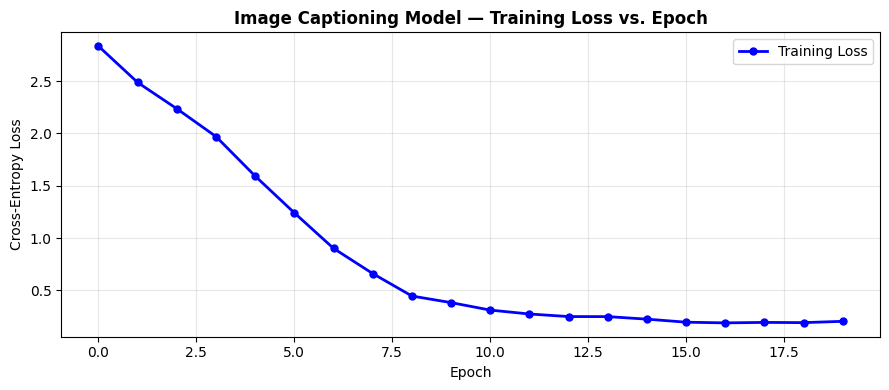

Initial loss: 2.8326
Final loss:   0.2053


In [10]:
plt.figure(figsize=(9, 4))
plt.plot(loss_history, 'b-o', linewidth=2, markersize=5, label='Training Loss')
plt.title('Image Captioning Model — Training Loss vs. Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Initial loss: {loss_history[0]:.4f}')
print(f'Final loss:   {loss_history[-1]:.4f}')

## 🔮 Step 10: Generate Captions (Greedy Decoding)

In [11]:
def generate_caption(img_id, max_len=20):
    """
    greedy decoding: at each step just pick the word with the highest score

    simple but not always optimal — beam search is better but more complex
    returns the full generated caption and the attention map for each word (useful for visualization)
    """
    # getting the pre-extracted image features
    features = tf.expand_dims(image_features[img_id].astype('float32'), 0)  # (1, 64, 2048)

    # initializing decoder state and starting token
    hidden   = decoder.get_initial_state(batch_size=1)
    word_in  = tf.expand_dims([START_IDX], 0)  # starting the sequence with the <start> token

    caption       = []
    attention_maps = []

    for _ in range(max_len):
        # decoding one word at a time
        logits, hidden, attn_w = decoder(word_in[0], features, hidden, training=False)

        # greedy selection: just take the word with the highest score
        pred_id = tf.argmax(logits[0]).numpy()
        pred_word = idx2word.get(pred_id, '<unk>')

        # stopping when we hit the <end> token — that means the caption is complete
        if pred_word == '<end>':
            break

        caption.append(pred_word)
        attention_maps.append(attn_w[0].numpy().reshape(8, 8))  # (8, 8) spatial map

        # feeding our prediction as the input for the next step
        word_in = tf.expand_dims([pred_id], 0)

    return ' '.join(caption), attention_maps


# Generate captions for sample images
print('Generated Captions vs Ground Truth:')
print('='*65)
for img_id in list(captions_data.keys())[:5]:
    generated, _ = generate_caption(img_id)
    gt = captions_data[img_id][0]
    print(f'Image: {img_id}')
    print(f'  Ground Truth: "{gt}"')
    print(f'  Generated:    "{generated}"')
    print()

Generated Captions vs Ground Truth:
Image: image_0000
  Ground Truth: "an old man reading a newspaper"
  Generated:    "a white cat sleeping on a sofa"

Image: image_0001
  Ground Truth: "two dogs running on a green field"
  Generated:    "children playing near a red building"

Image: image_0002
  Ground Truth: "a cat sitting on a wooden chair"
  Generated:    "a cat sitting on a wooden chair"

Image: image_0003
  Ground Truth: "two children running on the beach"
  Generated:    "a blue bicycle parked near the road"

Image: image_0004
  Ground Truth: "two dogs running on a green field"
  Generated:    "a young boy kicking a football"



## 🎯 Step 11: Visualize Attention Maps

The key insight of the 'Show, Attend and Tell' paper: we can visualize which image regions the model focuses on when generating each word.

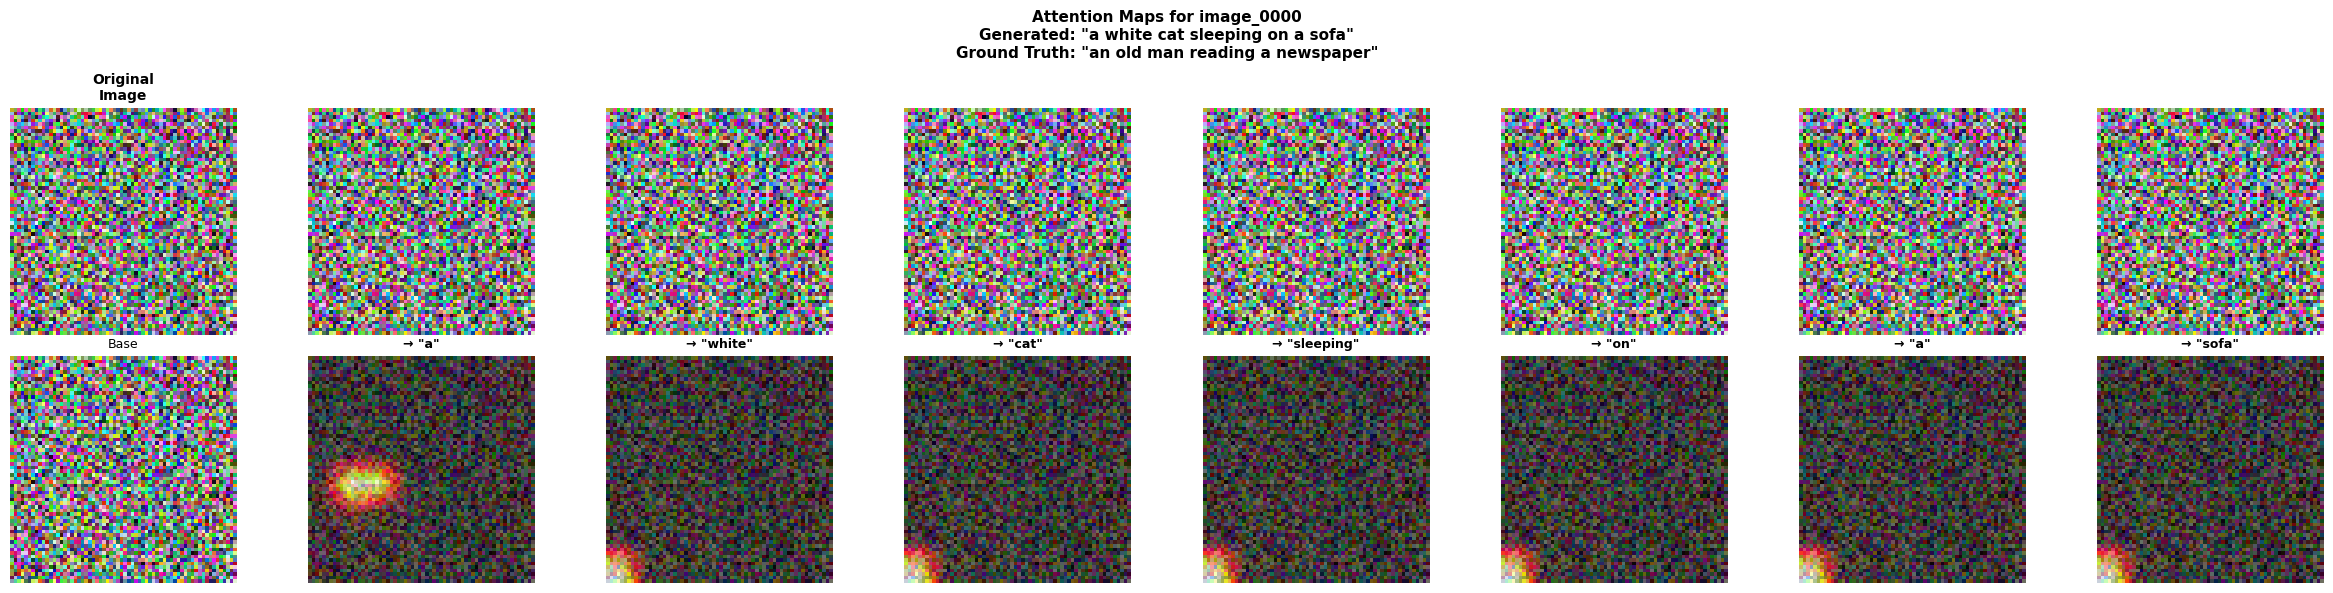

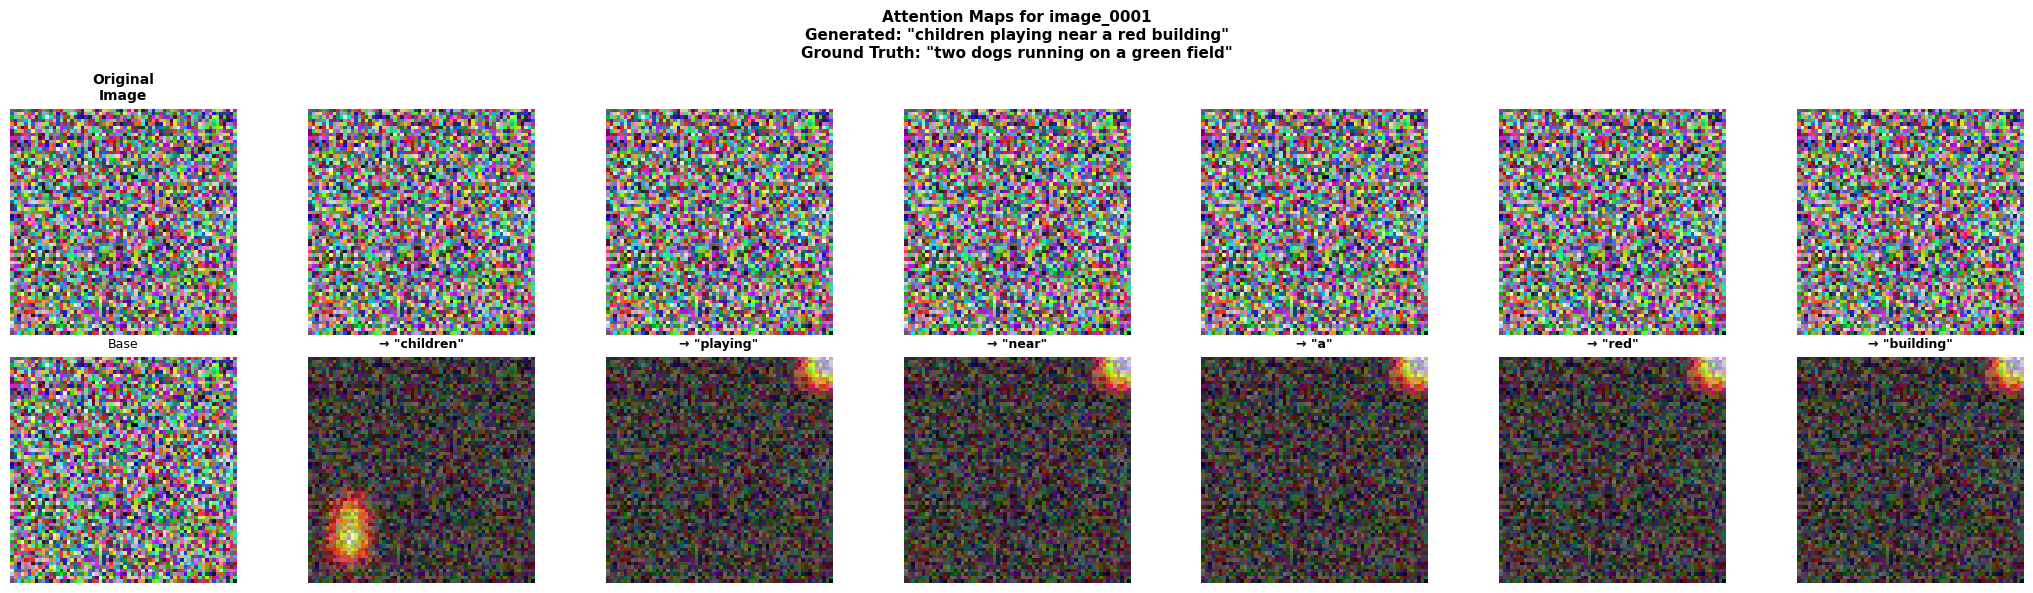

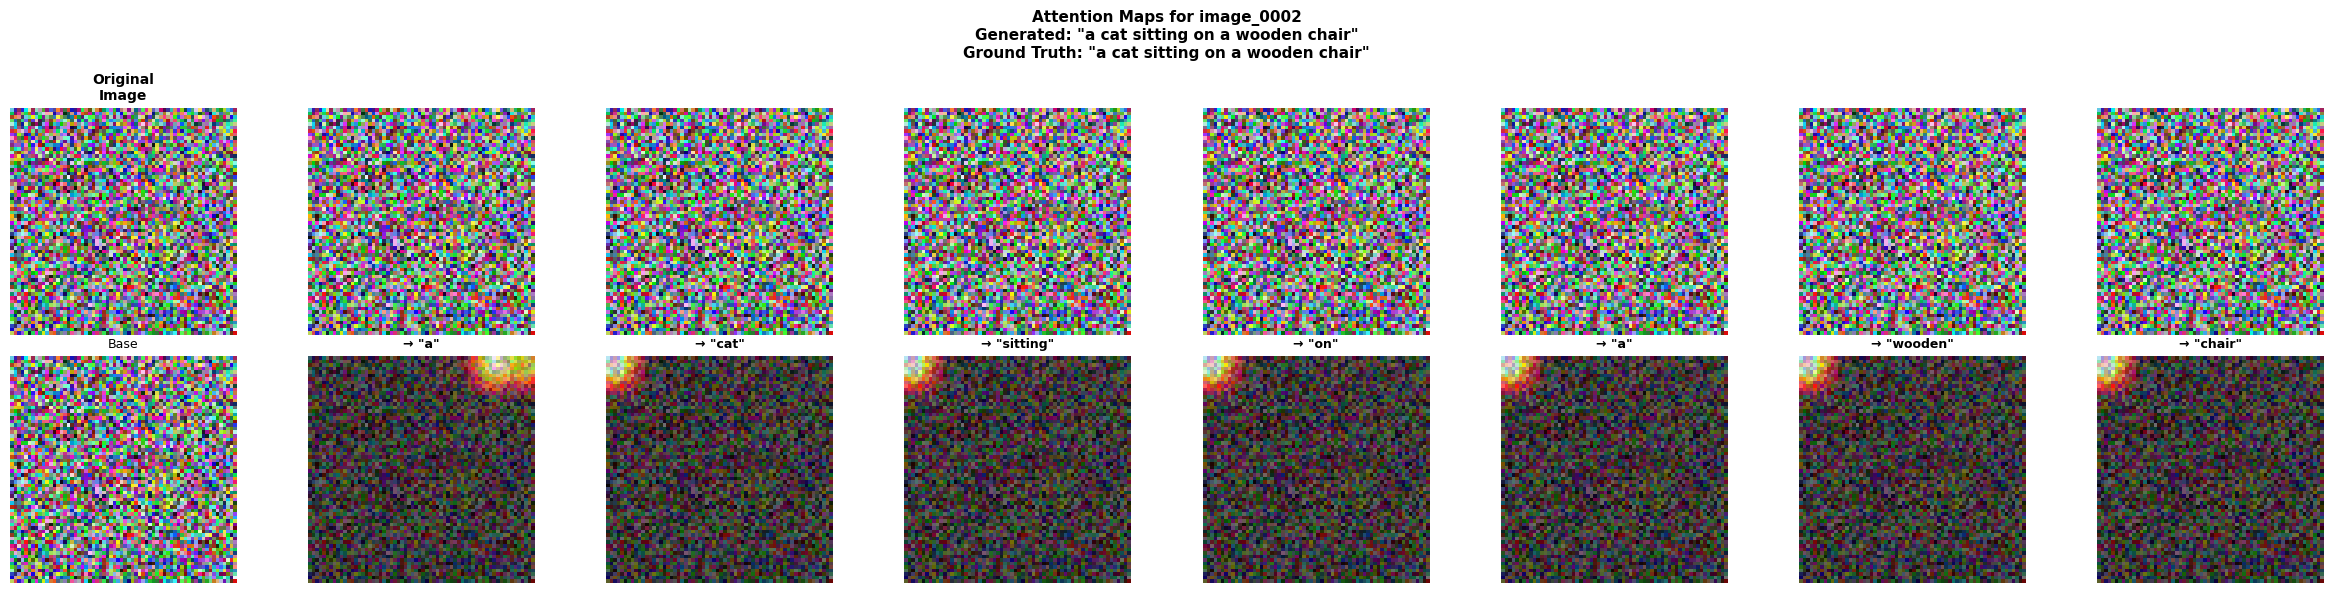

In [12]:
def visualize_attention(img_id, max_words=8):
    """
    showing which parts of the image the model focused on for each word it generated
    the attention map is an 8x8 grid of weights — brighter = more attention on that region
    """
    image = synthetic_images[img_id]
    caption, attention_maps = generate_caption(img_id)
    words = caption.split()

    n_words = min(len(words), max_words)
    if n_words == 0:
        print('No words generated!')
        return

    fig, axes = plt.subplots(2, n_words + 1, figsize=(3 * (n_words + 1), 6))

    # Top row: original image
    for ax in axes[0]:
        ax.imshow(image)
        ax.axis('off')
    axes[0, 0].set_title('Original\nImage', fontsize=10, fontweight='bold')

    # Bottom row: attention maps per word
    axes[1, 0].imshow(image)
    axes[1, 0].set_title('Base', fontsize=9)
    axes[1, 0].axis('off')

    for i in range(n_words):
        ax = axes[1, i + 1]
        if i < len(attention_maps):
            attn = attention_maps[i]  # (8, 8)
            # upscaling the 8x8 attention map to match the image size for overlay
            attn_resized = tf.image.resize(
                attn.reshape(8, 8, 1), [image.shape[0], image.shape[1]]
            ).numpy().squeeze()
            ax.imshow(image)
            ax.imshow(attn_resized, cmap='hot', alpha=0.55)
            ax.set_title(f'→ "{words[i]}"', fontsize=9, fontweight='bold')
        ax.axis('off')

    plt.suptitle(
        f'Attention Maps for {img_id}\nGenerated: "{caption}"\nGround Truth: "{captions_data[img_id][0]}"',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Visualize for 3 sample images
for img_id in list(captions_data.keys())[:3]:
    visualize_attention(img_id)

## 📊 Step 12: Attention Weight Distribution Analysis

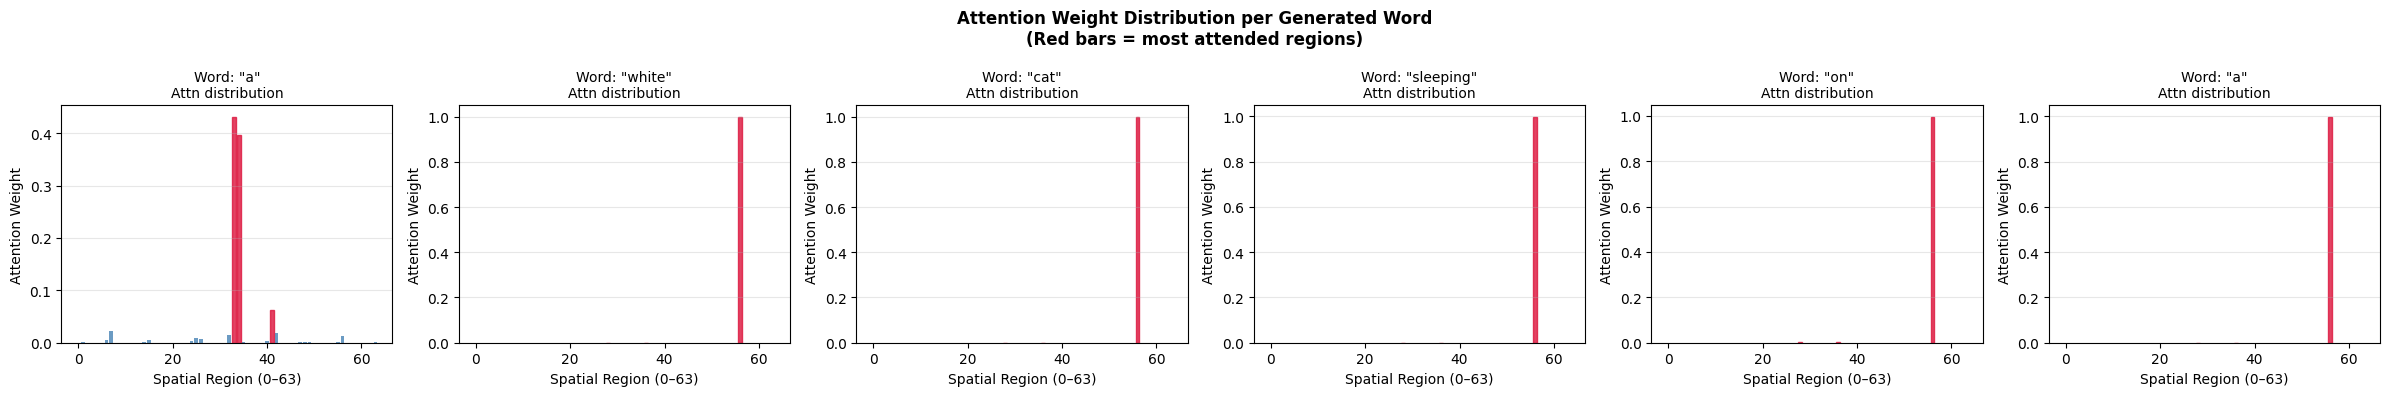

In [13]:
# looking at how evenly or sharply attention is distributed across the 64 image regions per word
sample_img = list(captions_data.keys())[0]
caption, attn_maps = generate_caption(sample_img, max_len=6)
words = caption.split()

if len(words) > 0 and len(attn_maps) > 0:
    n_w = min(len(words), len(attn_maps))
    fig, axes = plt.subplots(1, n_w, figsize=(4 * n_w, 4))
    if n_w == 1:
        axes = [axes]

    for i, (ax, word) in enumerate(zip(axes, words[:n_w])):
        attn_flat = attn_maps[i].flatten()  # 64 values
        bars = ax.bar(range(64), attn_flat, color='steelblue', alpha=0.8)
        # Highlight top-3 attended regions
        top3 = np.argsort(attn_flat)[-3:]  # finding the 3 most attended regions
        for idx in top3:  # highlighting them in red
            bars[idx].set_color('crimson')
        ax.set_title(f'Word: "{word}"\nAttn distribution', fontsize=10)
        ax.set_xlabel('Spatial Region (0–63)')
        ax.set_ylabel('Attention Weight')
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Attention Weight Distribution per Generated Word\n(Red bars = most attended regions)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No attention maps to display (model may need more training).')

---

## 📝 Summary

| Component | Role | Implementation |
|-----------|------|----------------|
| **InceptionV3 Encoder** | Extract spatial image features | Pre-trained CNN, frozen |
| **Bahdanau Attention** | Dynamically weight image regions | Learned alignment scores |
| **GRU Decoder** | Generate captions word-by-word | Conditioned on context + prev word |
| **Teacher Forcing** | Training stabilization | Feed ground truth as decoder input |
| **Greedy Decoding** | Inference | Pick argmax word at each step |

**Key Insight:** Attention allows the model to focus on different image regions for each word. For "dog", it attends to the animal region. For "park", it attends to the background.

---

## ❓ Viva / Self-Check Questions

1. **What is the Encoder-Decoder architecture?** Why is it necessary for tasks like image captioning?

2. **Explain Bahdanau Attention.** How does it compute attention weights? What do they represent physically?

3. **What is Teacher Forcing?** Why is it used during training but NOT during inference?

4. **What is Greedy Decoding?** What is Beam Search, and how does it improve upon greedy decoding?

5. **Why do we use InceptionV3 as the encoder and not train a CNN from scratch?** What is this technique called?

6. **Why does the attention mechanism visualize WHICH part of the image is looked at for each word?** What property of attention makes this possible?

7. **What is the difference between 'Hard Attention' and 'Soft Attention'?** Which one is differentiable (can be trained with gradient descent)?

8. **What is the BLEU score?** How is it used to evaluate image caption quality automatically?